# MHealth Data: Gyro, Magnetometer, Acceleration EDA

## Table of Contents

0. Import Libraries & Data

In [1]:
%pip install -r requirements.txt


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


In [2]:
import csv
import sqlite3
import pandas as pd
import numpy as np
import math
import sklearn
import os
from pathlib import Path
import sys
sys.path.append('../')
import src.initiate_database as id
from scripts.helper_functions import apply_butterworth, preprocess_full_df, window_generator
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
import imblearn
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import classification_report
import scipy
from scipy import signal
import sqlite3
import mpl_toolkits
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML, display
from matplotlib import animation
from scipy.signal import find_peaks, butter, filtfilt
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['animation.embed_limit'] = 50

Let's connect to the database and access the data description and general information. Run the following code block.

In [3]:
#DB_FILE = "/Users/jaeahkim/Google Drive/My Drive/Personal Projects/FitnessRecommender/data/raw/mHealth.db"

conn = id.get_connection()
df = pd.read_sql("SELECT * FROM sensor_data ORDER BY subject_id ASC", conn)
conn.close()

Connecting to database...


There are a total of 1,211,745 entries in the dataset, for a total of 10 research subjects. There are no null values.

## 1. Contextual Information

The dataset contains over a million rows of sensor information. It is important to be able to know how to interpret the sensor data values. I refer to the dataset documentation for a lot of this section, as well as some auxiliary online research.

### Experimental Set Up  

The dataset comprises of body motion and vital (namely ECG) sign recordings for ten volunteers of diverse profile. These ten volunteers performed 12 physical activities, labeled in the dataset as follows. Each activity was done for 1 minute, except for activities 6, 7, 8, and 12. Those activities were carried out as 20 reps per activity.

| **Label** |        **Activity**       |
|:---------:|:-------------------------:|
|     0     |       Null Class      |
|     1     |       Standing Still      |
|     2     |    Sitting and Relaxing   |
|     3     |         Lying Down        |
|     4     |          Walking          |
|     5     |      Climbing Stairs      |
|     6     |    Waist Bends Forward    |
|     7     | Frontal Elevation of Arms |
|     8     | Knees Bending (Crouching) |
|     9     |          Cycling          |
|     10    |          Jogging          |
|     11    |          Running          |
|     12    |   Jump (Front and Back)   |

Shimmer2 [BUR10] wearable sensors were used for all of the recordings. The sensors were placed on the subject's chest, right wrist, and left ankle.

The sensor positioned on the chest also provides 2-lead ECG measurements, which was not used for the development of the recognition model in the original publication, but will be used for model training in this project. 

All sensor modalities were recorded at a sampling rate of 50Hz, meaning a 5-second window is 250 rows. The activities were collected in an out-of-lab environment with no constraints on the execution of activities, with the exception that the subject should try their best. 

Units are in m/s^2 for acceleration, deg/s for gyroscope, local µT for magnetometer, and mV for ECG data. 


### The Variables and How to Interpret Them

#### Acceleration Data

Sources:
https://www.phidgets.com/docs/Accelerometer_Guide

The motion sensor gives 3-axis acceleration data: X, Y, and Z. The more positive the value is, the faster the arm/ankle is moving in the positive direction on the respective axis, and likewise for negative values. 
In order to interpret these values, it is important to understand what they mean. 

The accelerometer measures linear acceleration, but is always influenced by gravity. If the sensor is sitting perfectly still on a table, the acceleration magnitude will be approximately 9.81m/s^2. This allows me to calculate tilt, because if the Z-axis reads 9.81m/s^2, the sensor is flat, but if the X-axis reads 9.81m/s^2, it's standing on its side. Sharp movements, such as jumping, or kicking a ball, will result in a high magnitude. The best proxy for intensity from this data is standard deviation. High variance in acceleration should correlate with high physical exertion. 


#### Gyroscope Data

Sources: 
https://www.phidgets.com/docs/Gyroscope_Guide

Gyroscopes measure the rate at which the sensor is rotating (angular velocity). By adding up or integrating all of the readings of angular velocity over time, I can track the angle of rotation from where the sensor started. However, unlike magnetometers and accelerometers, there is no fixed frame of reference that can be measured by the gyroscope itself to determine a starting angle. Additionally, unlike the accelerometer, it is not affected by gravity. 

A reading of 0deg/s means that the device is not rotating, even if the device is moving linearly. High values, on the other hand, indicate rapid changes in posture or limb rotation, such as frontal elevation of arms. 

It is important to note that there is a drift problem in most gyroscopes. Errors will accumulate over time if data values are integrated to find an angle. Therefore, the other sensors are needed to "correct" the gyroscope data. 


#### Magnetometer Data

Sources: 
https://www.phidgets.com/docs/Magnetometer_Guide

The magnetometer measures the strength and direction of the magnetic field in µT. In a "clean" environment, it points toward Magnetic North, essentially acting as a  digital compass. By comparing x and y magnetic values, it's possible to determine which direction the user is facing. 

The magnetometer is the only sensor that can differentiate between certain movements and directions. For example, if the user moves from a "Face North" squat to a "Face East" lunge, the magnetometer is the only sensor that will clearly show that 90 degree change in the global frame. 

It is important to note that because it measures µT, it is highly sensitive to its environment, namely magnets, speakers, or steel beams in a gym. It is likely to react to the environment as the user moves through it. 

In [5]:
# Define data groups dictionary
data_groups = {
    "chest_acceleration": [
        "x_accel_chest",
        "y_accel_chest",
        "z_accel_chest"
    ],
    "ecg": [
        "ecg_l1",
        "ecg_l2"
    ],
    "ankle_acceleration": [
        "x_accel_l_ankle",
        "y_accel_l_ankle",
        "z_accel_l_ankle"
    ],
    "ankle_gyro": [
        "x_gyro_l_ankle",
        "y_gyro_l_ankle",
        "z_gyro_l_ankle"
    ],
    "ankle_magnet": [
        "x_magnet_l_ankle",
        "y_magnet_l_ankle",
        "z_magnet_l_ankle"
    ],
    "arm_acceleration": [
        "x_accel_r_arm",
        "y_accel_r_arm",
        "z_accel_r_arm"
    ],
    "arm_gyro": [
        "x_gyro_r_arm",
        "y_gyro_r_arm",
        "z_gyro_r_arm"
    ],
    "arm_magnet": [
        "x_magnet_r_arm",
        "y_magnet_r_arm",
        "z_magnet_r_arm"
    ]
}

### The Butterworth Filter

The Butterworth filter is a signal processing filter that is designed to have a frequency response as flass as possible in the passband. It's primarily used to remove high-frequency noise while preserving low-frequency components. The scipy.signal module provides four different types of filters: `lowpass`, `highpass`, `bandpass`, and `bandstop`. 

`lowpass` and `bandpass` will be used in this project. 

#### The Low-Pass Filter

A low-pass filter basically removes high-frequency "jitter" or noise. It allows signals with a frequency lower than a specific cutoff frequency to pass and blocks everything higher. 

In the context of this project: human body movements such as walking or running are relatively slow, low-frequency events. However, sensors produce high-frequency electronic noise or "vibrations". Therefore, the low-pass filter will be used on the accelerometer, gyroscope, and magnetometer data. The only difference is that the magnetometer is incredibly sensitive to local magnetic interference, which causes the orientation to drift or flutter even if the subject isn't moving or changing orientation much. Therefore, the low-pass frequency threshold will be very low for the magnetometer, as compared to that of the accelerometer and gyroscope. 

#### The Band-Pass Filter

The band-pass filter allows frequencies within a specific range/band to pass, while blocking frequencies that are either too low or too high. Basically, it isolates a specific "middle" section of the signal. This is essential for cleaning ECG data, because it removes baseline wander on the low end, and muscle noise or power line interference on the high end. As a result, it centers the heartbeat signal and makes the R-peaks much easier to detect later on. 


How do I find out which cutoff frequencies should be used for the accelerometer, gyroscope, magnetometer, and ECG respectively? 

Let's look at the behavior of the acceleration, rotation, and orientation data for the chest, arm, and ankle respectively. I'll look at the data for standing (L1) and running (L11) to get an idea of low and high intensity activities.

##### 1. Arm

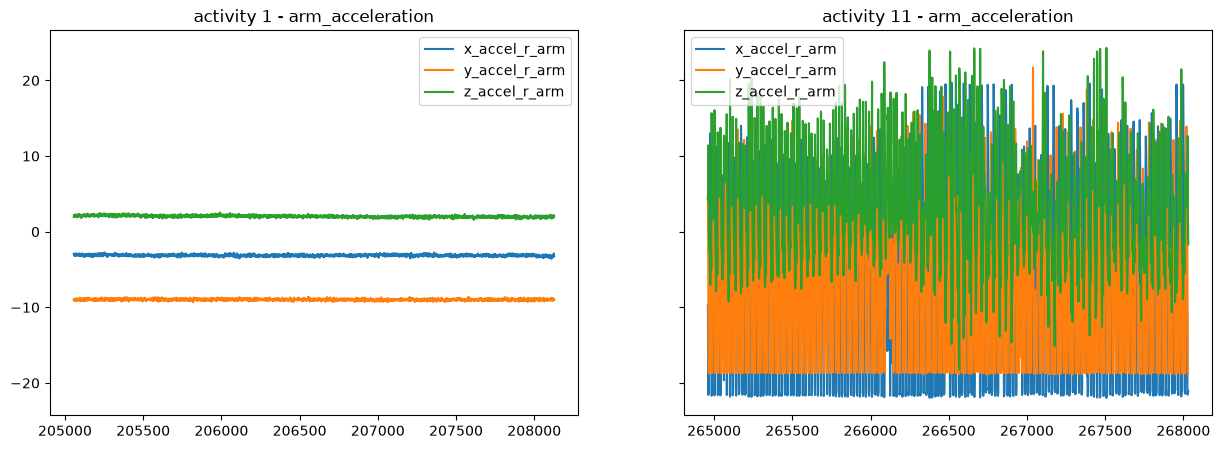

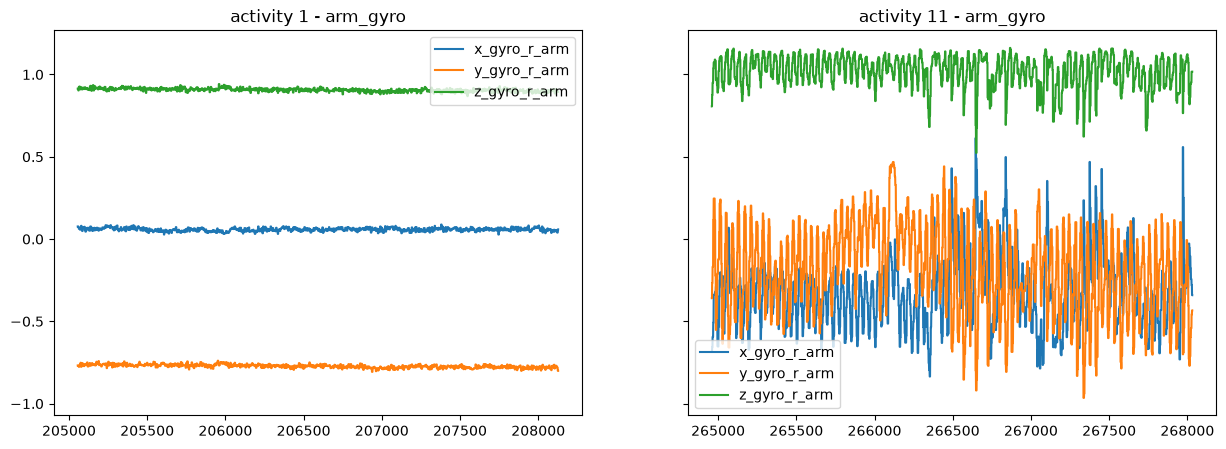

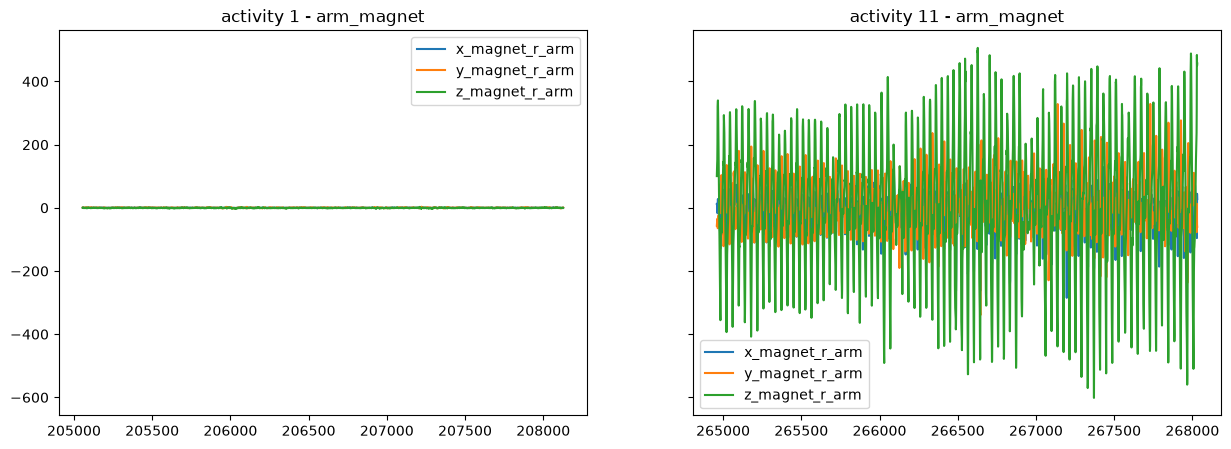

In [5]:
arm_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "arm" in group]

# Include only standing still and running activities
arm_df = df[(df["activity_label"] == 1) | (df["activity_label"] == 11)]

subject_id = 1

for group, measurements in arm_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    arm_subset = arm_df[columns]
    
    fig, axes = plt.subplots(1, 2, figsize = (15, 5), sharey = True)

    for i, activity in enumerate([1, 11]):
        arm_subsubset = arm_subset[(arm_subset["activity_label"] == activity) & (arm_subset["subject_id"] == subject_id)]
        axes[i].plot(arm_subsubset[measurements])
        axes[i].legend(measurements)
        axes[i].set_title(f"activity {activity} - {group}")

##### 2. Chest

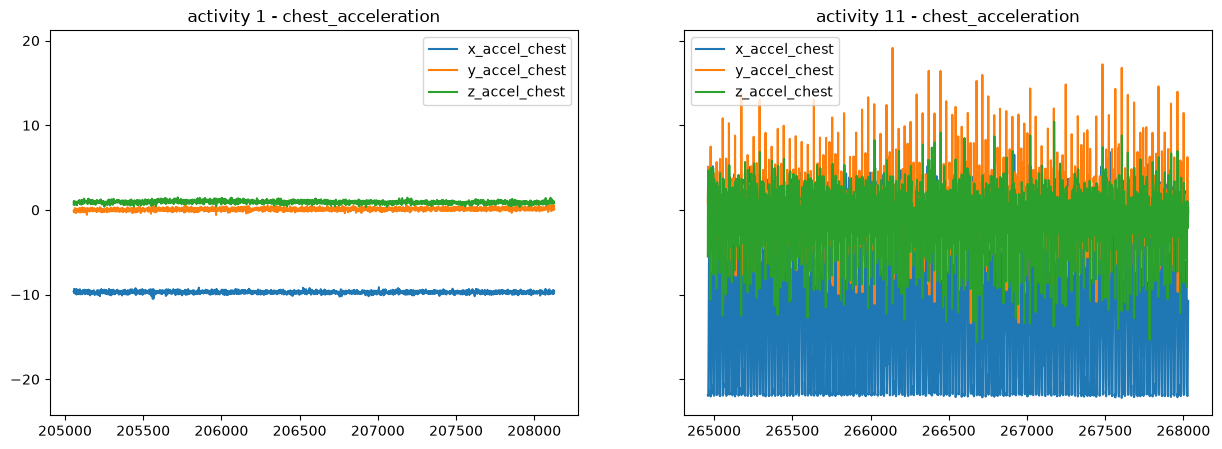

In [6]:
chest_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "chest" in group]

# Include only standing still and running activities
chest_df = df[(df["activity_label"] == 1) | (df["activity_label"] == 11)]

subject_id = 1

for group, measurements in chest_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    chest_subset = chest_df[columns]
    
    fig, axes = plt.subplots(1, 2, figsize = (15, 5), sharey = True)

    for i, activity in enumerate([1, 11]):
        chest_subsubset = chest_subset[(chest_subset["activity_label"] == activity) & (chest_subset["subject_id"] == subject_id)]
        axes[i].plot(chest_subsubset[measurements])
        axes[i].legend(measurements)
        axes[i].set_title(f"activity {activity} - {group}")

##### 3. Ankle

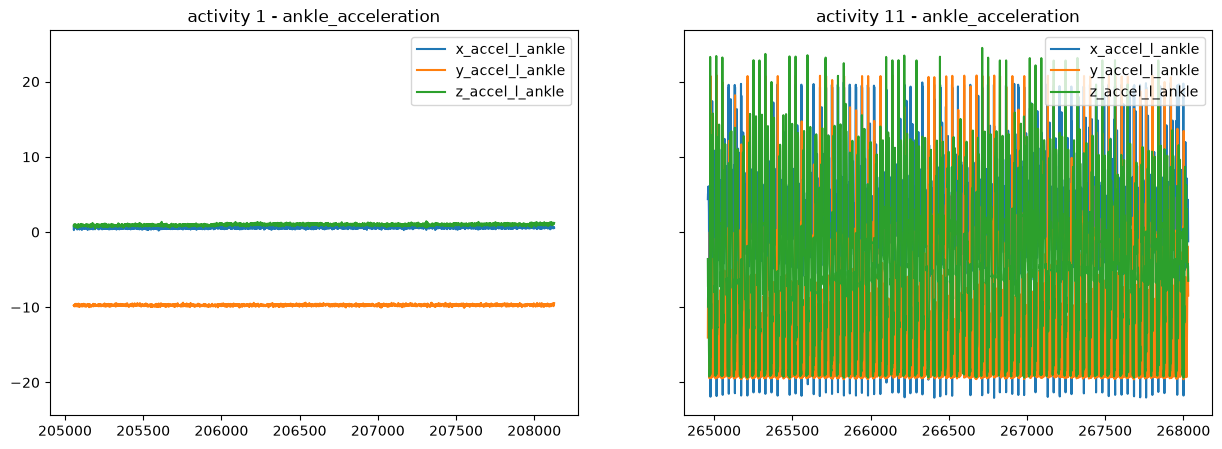

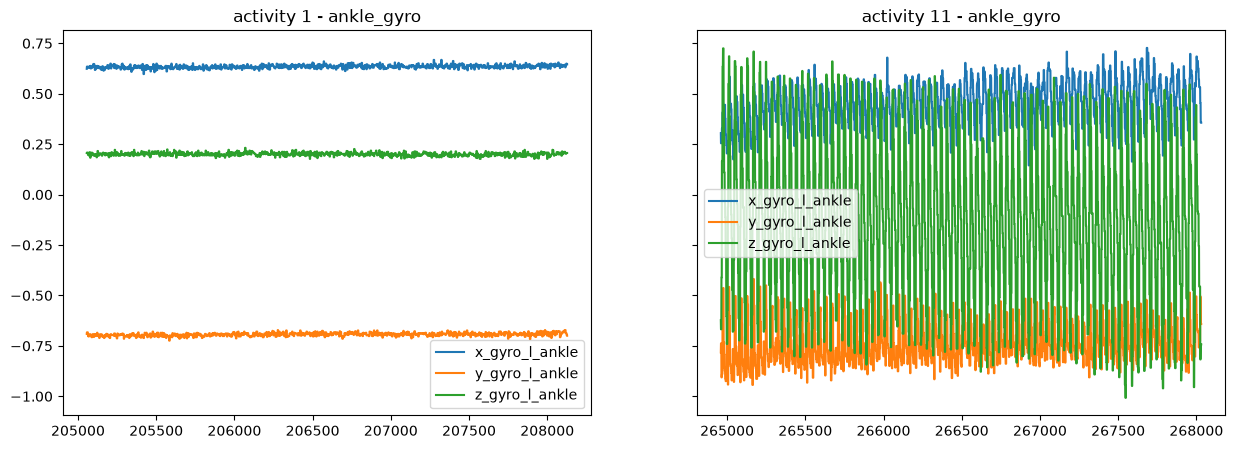

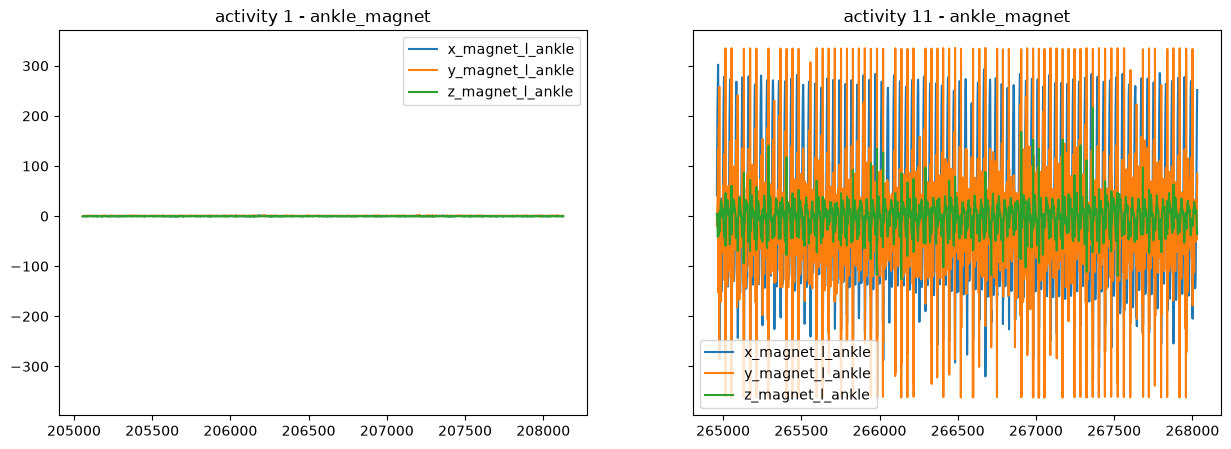

In [7]:
ankle_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "ankle" in group]

# Include only standing still and running activities
ankle_df = df[(df["activity_label"] == 1) | (df["activity_label"] == 11)]

subject_id = 1

for group, measurements in ankle_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    ankle_subset = ankle_df[columns]
    
    fig, axes = plt.subplots(1, 2, figsize = (15, 5), sharey = True)

    for i, activity in enumerate([1, 11]):
        ankle_subsubset = ankle_subset[(ankle_subset["activity_label"] == activity) & (ankle_subset["subject_id"] == subject_id)]
        axes[i].plot(ankle_subsubset[measurements])
        axes[i].legend(measurements)
        axes[i].set_title(f"activity {activity} - {group}")

#### To Summarize

Not only does the sensor data manifest differently according to the sensor type, it also manifests differently according to body part and activity. Making the filter too aggressive may wash out the data for low or high intensity activity, and making the filter too permissive may not smooth or clean the data efficiently. 

One way I can address these discrepancies is to apply the Butterworth filter to the data according to the activity, which would probably be the most comprehensive method. However, it's not very replicable, nor is it time efficient. 

Instead, I'll keep the filters at certain cut off frequencies but use the difference (noise) as a feature. Intuitively, I'd expect the noise to be relatively low for the "standing still" activity compared to the "running" or "jumping" activity. This gives me the chance to transform this filtering issue into a useful feature for my model. 

| **Sensor** | **Filter Type** | **Cutoff Frequency (fc)** |                  **Goal**                  |
|:----------:|:---------------:|:-------------------------:|:------------------------------------------:|
|    Accel   |     Low-Pass    |            12 Hz           |       Remove device rattle/vibration       |
|    Gyro    |     Low-Pass    |            12 Hz           |        Smooth out rotational "noise"       |
|   Magnet   |     Low-Pass    |           2 Hz          | Stabilize orientation against interference |
|     ECG    |    Band-Pass    |        [0.5, 24] Hz       |     Isolate the R-peak and remove drift    |

The butterworth function for each respective sensor is defined in helper_functions.py.

In [6]:
df_filtered = preprocess_full_df(df)

In [21]:
processed_columns = [col for col in df_filtered.columns if col not in ["activity_label", "id", "subject_id"]]
processed_columns
processed_column_dict = {}
processed_column_dict["subject_id"] = "INTEGER NOT NULL"
for column in processed_columns:
    processed_column_dict[column] = "REAL NOT NULL"
processed_column_dict["activity_label"] = "INTEGER NOT NULL"

In [22]:
import json
with open('../column_specs.json', 'r') as f:
    file_data = json.load(f)

file_data['processed'].update(processed_column_dict)
with open('../column_specs.json', 'w') as f:
    json.dump(file_data, f, indent = 4)

In [8]:
df_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 1211745 entries, 0 to 1211744
Data columns (total 49 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   id                     1211745 non-null  int64  
 1   subject_id             1211745 non-null  int64  
 2   x_accel_chest          1211745 non-null  float64
 3   y_accel_chest          1211745 non-null  float64
 4   z_accel_chest          1211745 non-null  float64
 5   ecg_l1                 1211745 non-null  float64
 6   ecg_l2                 1211745 non-null  float64
 7   x_accel_l_ankle        1211745 non-null  float64
 8   y_accel_l_ankle        1211745 non-null  float64
 9   z_accel_l_ankle        1211745 non-null  float64
 10  x_gyro_l_ankle         1211745 non-null  float64
 11  y_gyro_l_ankle         1211745 non-null  float64
 12  z_gyro_l_ankle         1211745 non-null  float64
 13  x_magnet_l_ankle       1211745 non-null  float64
 14  y_magnet_l_ankle       121174

In [10]:
df_filtered[['x_accel_l_ankle', 'x_accel_l_ankle_filt']]

,x_accel_l_ankle,x_accel_l_ankle_filt
0,2.1849,2.184840
1,2.3876,2.337221
2,2.4086,2.370988
3,2.1814,2.328984
4,2.4173,2.298530
...,...,...
1211740,1.7849,1.825548
1211741,1.8687,1.808066
1211742,1.6928,1.676544
1211743,1.5279,1.600638


Let's see the effects on each body part group data.

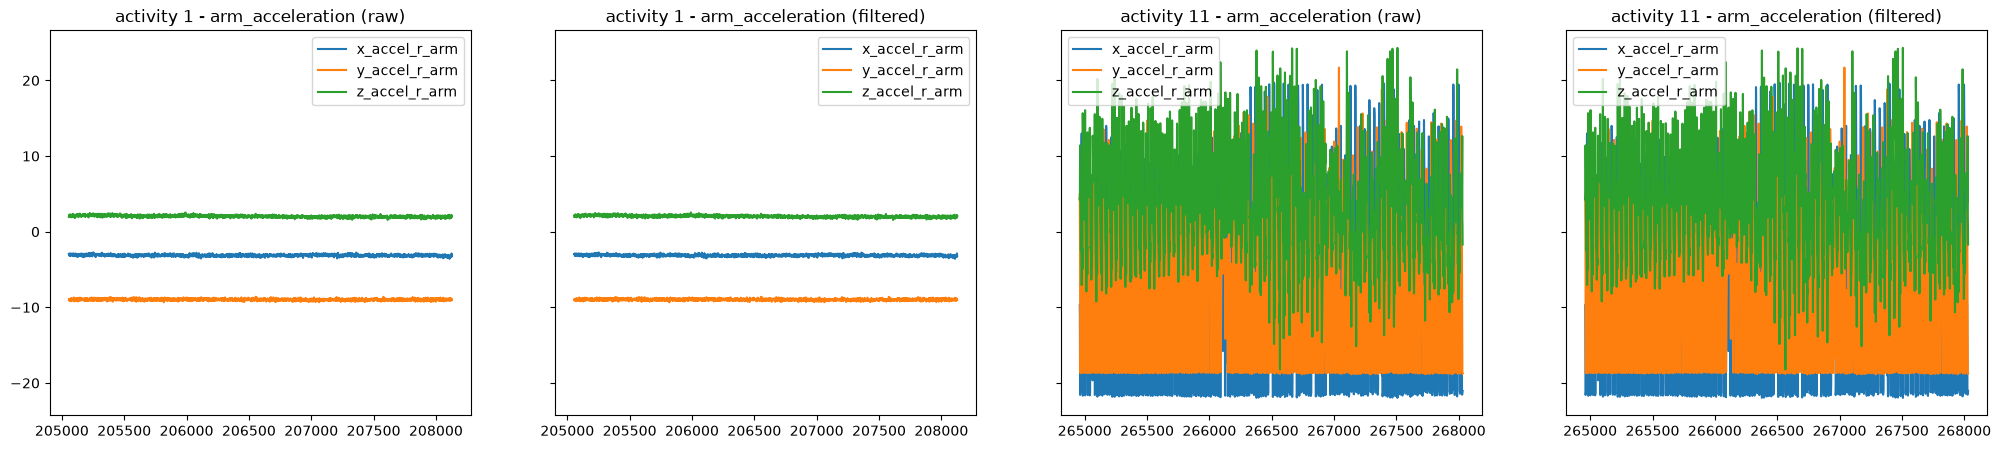

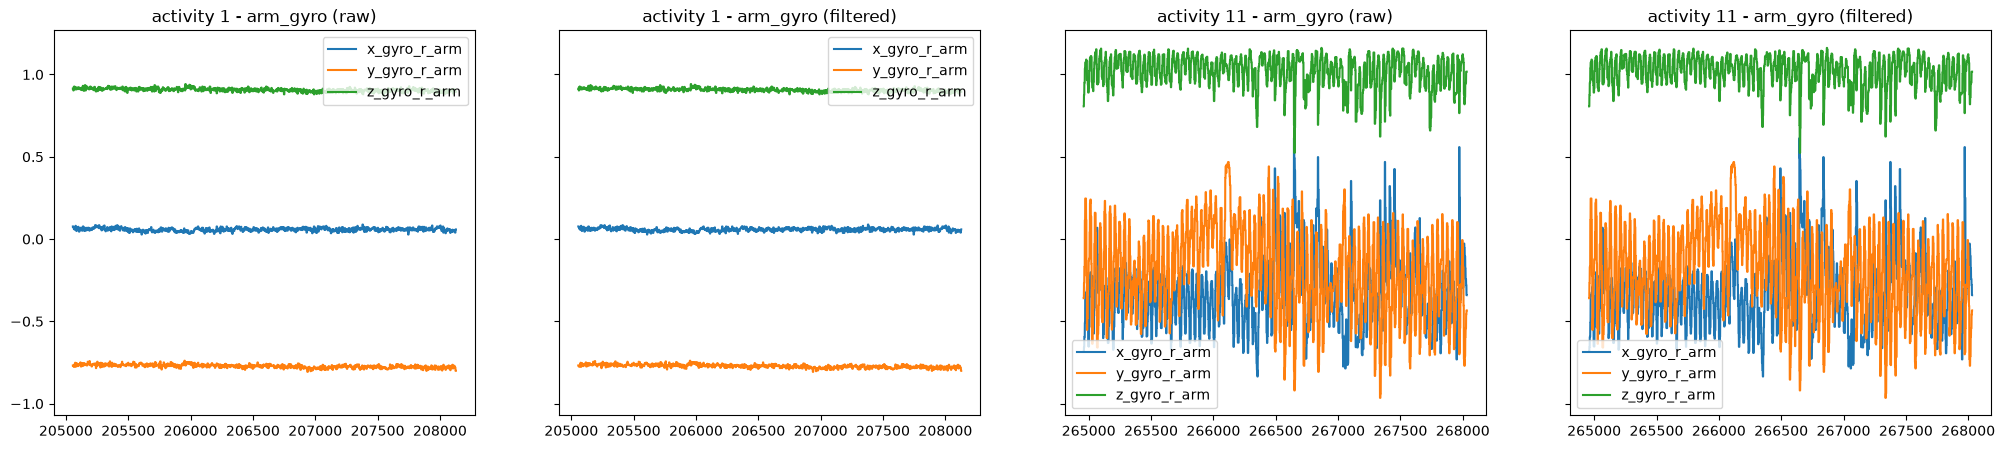

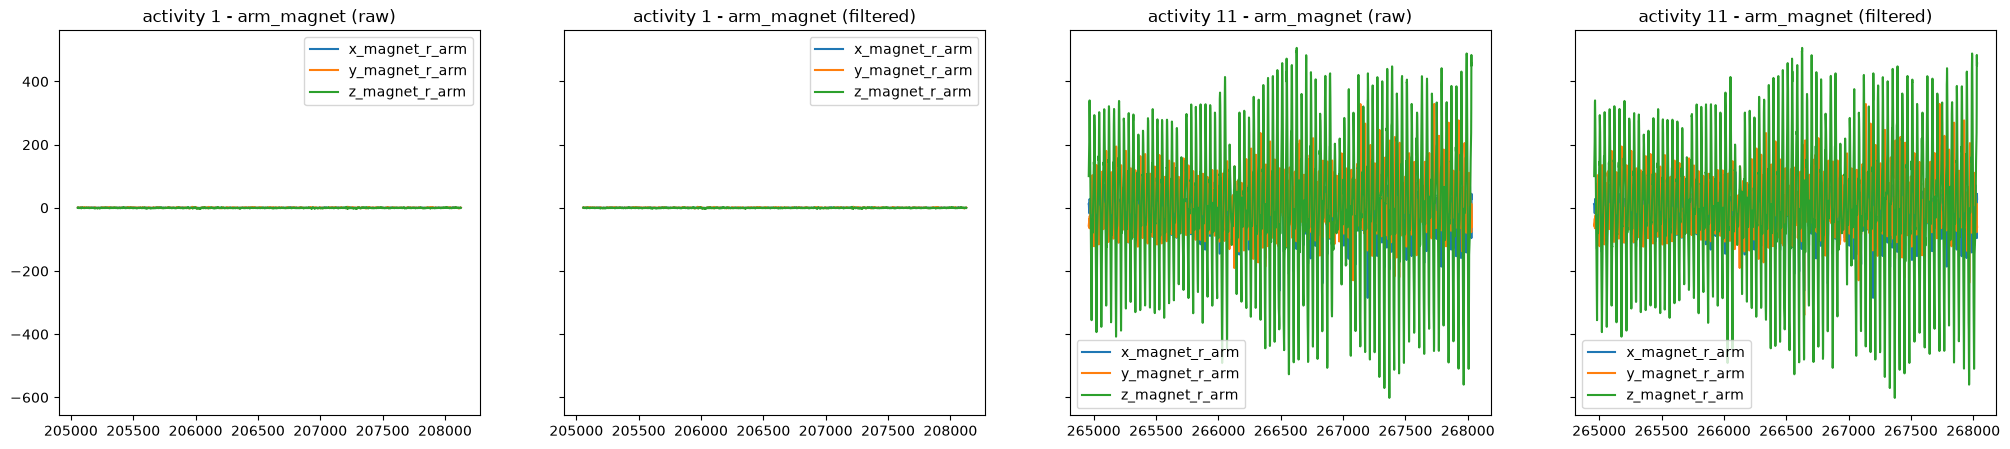

In [11]:
arm_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "arm" in group]

# Include only standing still and running activities
arm_filt_df = df_filtered[(df_filtered["activity_label"] == 1) | (df_filtered["activity_label"] == 11)]

subject_id = 1

for group, measurements in arm_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    arm_subset = arm_df[columns]
    arm_filt_subset = arm_filt_df[columns]
    
    fig, axes = plt.subplots(1, 4, figsize = (25, 5), sharey = True)

    for idx, activity in enumerate([1, 11]):
        raw_data = arm_subset[(arm_subset["activity_label"] == activity) & (arm_subset["subject_id"] == subject_id)]
        filt_data = arm_filt_subset[(arm_filt_subset["activity_label"] == activity) & (arm_filt_subset["subject_id"] == subject_id)]

        # Activity 1: axes 0 and 1, Activity 11: axes 2 and 3
        raw_ax_idx = idx * 2
        filt_ax_idx = idx * 2 + 1

        axes[raw_ax_idx].plot(raw_data[measurements])
        axes[raw_ax_idx].set_title(f"activity {activity} - {group} (raw)")
        axes[raw_ax_idx].legend(measurements)

        axes[filt_ax_idx].plot(filt_data[measurements])
        axes[filt_ax_idx].set_title(f"activity {activity} - {group} (filtered)")
        axes[filt_ax_idx].legend(measurements)

    plt.show()

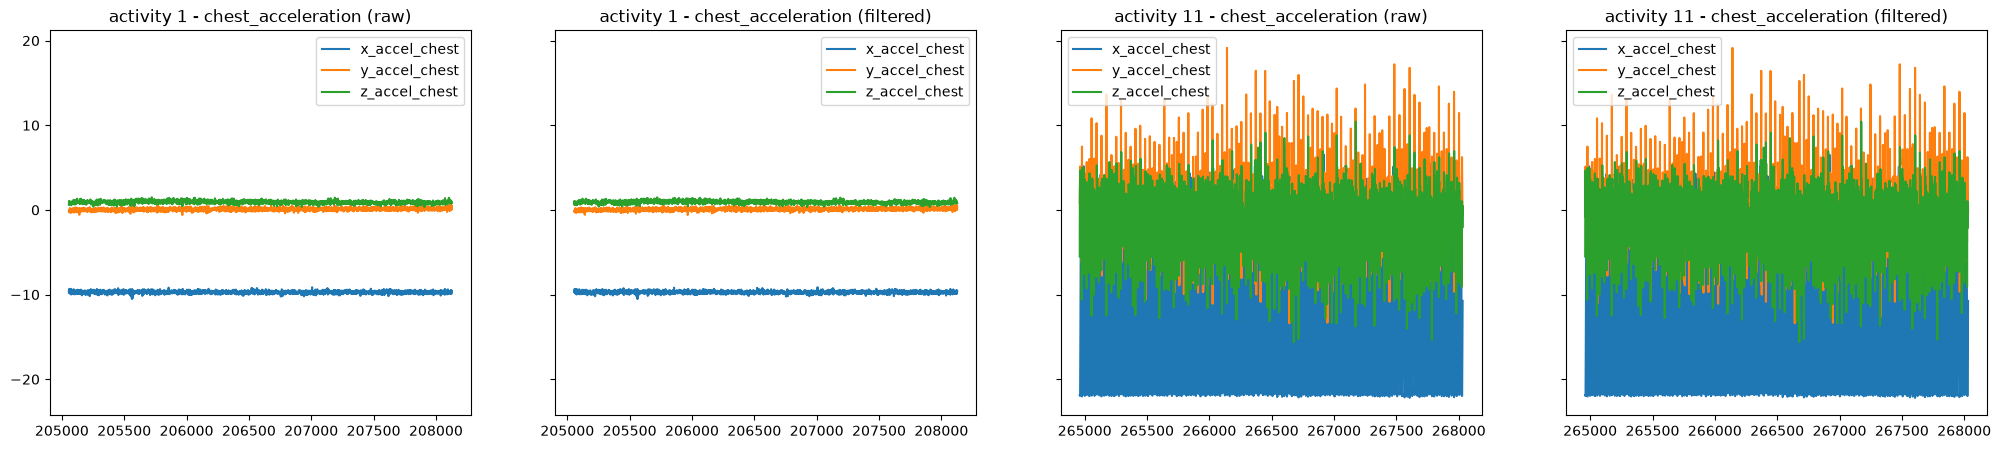

In [13]:
chest_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "chest" in group]

# Include only standing still and running activities
chest_filt_df = df_filtered[(df_filtered["activity_label"] == 1) | (df_filtered["activity_label"] == 11)]

subject_id = 1

for group, measurements in chest_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    chest_subset = chest_df[columns]
    chest_filt_subset = chest_filt_df[columns]
    
    fig, axes = plt.subplots(1, 4, figsize = (25, 5), sharey = True)

    for idx, activity in enumerate([1, 11]):
        raw_data = chest_subset[(chest_subset["activity_label"] == activity) & (chest_subset["subject_id"] == subject_id)]
        filt_data = chest_filt_subset[(chest_filt_subset["activity_label"] == activity) & (chest_filt_subset["subject_id"] == subject_id)]

        # Activity 1: axes 0 and 1, Activity 11: axes 2 and 3
        raw_ax_idx = idx * 2
        filt_ax_idx = idx * 2 + 1

        axes[raw_ax_idx].plot(raw_data[measurements])
        axes[raw_ax_idx].set_title(f"activity {activity} - {group} (raw)")
        axes[raw_ax_idx].legend(measurements)

        axes[filt_ax_idx].plot(filt_data[measurements])
        axes[filt_ax_idx].set_title(f"activity {activity} - {group} (filtered)")
        axes[filt_ax_idx].legend(measurements)

    plt.show()

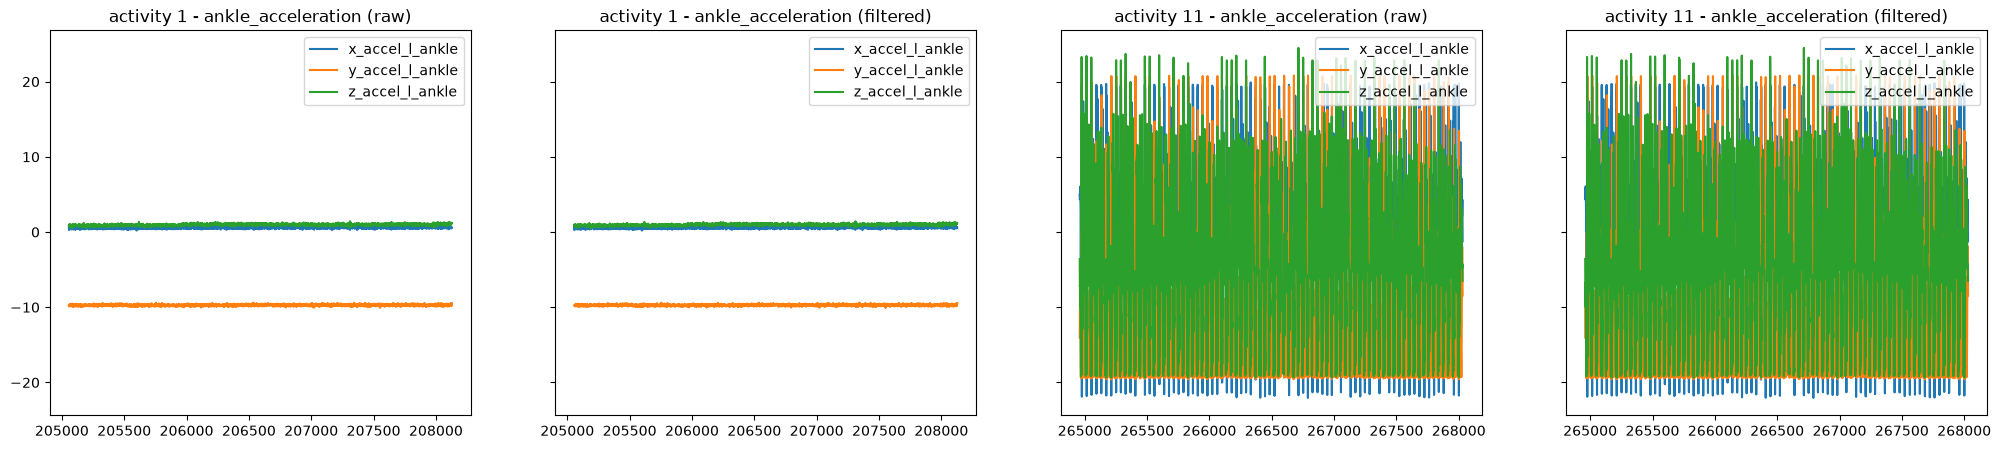

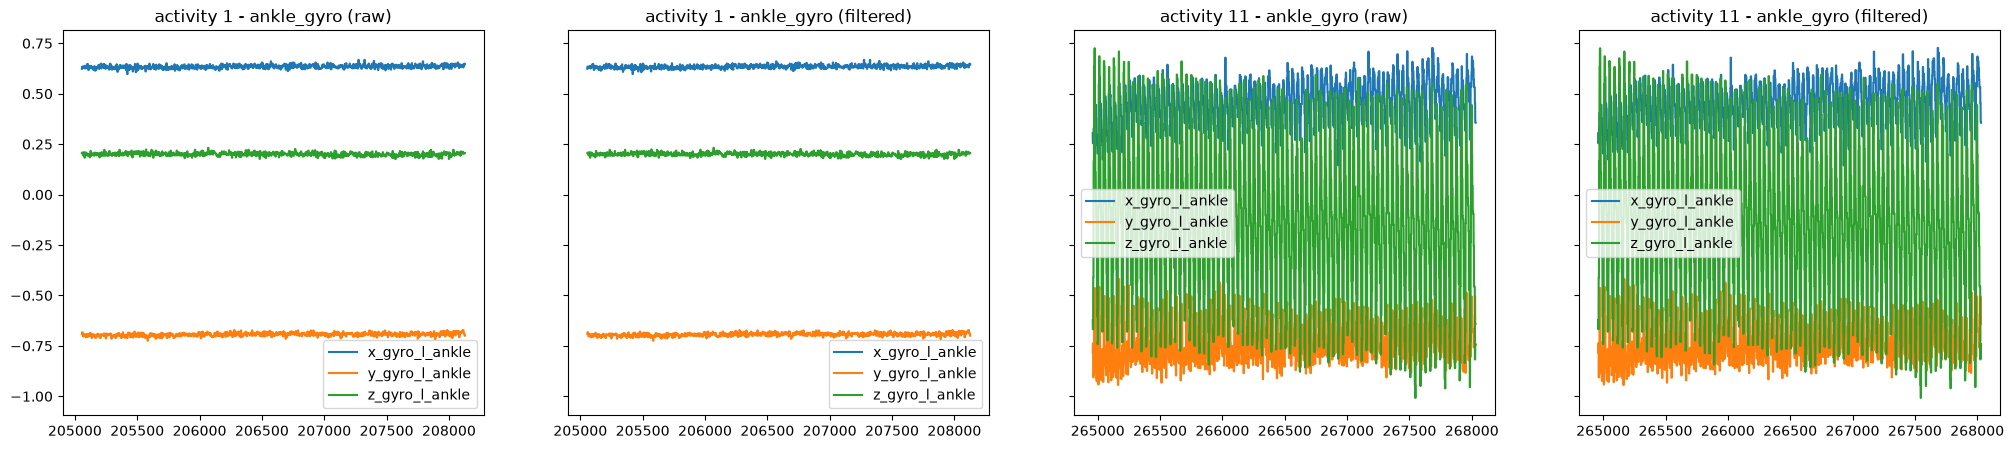

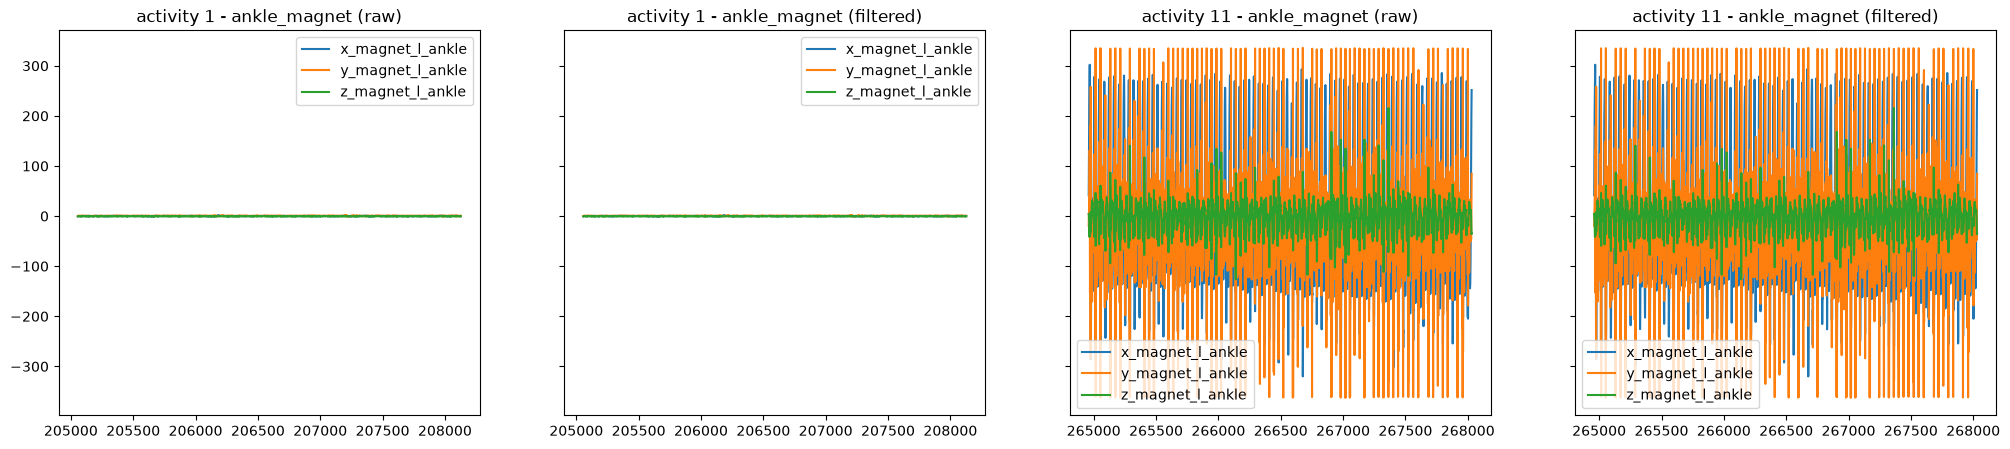

In [12]:
ankle_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "ankle" in group]

# Include only standing still and running activities
ankle_filt_df = df_filtered[(df_filtered["activity_label"] == 1) | (df_filtered["activity_label"] == 11)]

subject_id = 1

for group, measurements in ankle_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    ankle_subset = ankle_df[columns]
    ankle_filt_subset = ankle_filt_df[columns]
    
    fig, axes = plt.subplots(1, 4, figsize = (25, 5), sharey = True)

    for idx, activity in enumerate([1, 11]):
        raw_data = ankle_subset[(ankle_subset["activity_label"] == activity) & (ankle_subset["subject_id"] == subject_id)]
        filt_data = ankle_filt_subset[(ankle_filt_subset["activity_label"] == activity) & (ankle_filt_subset["subject_id"] == subject_id)]

        # Activity 1: axes 0 and 1, Activity 11: axes 2 and 3
        raw_ax_idx = idx * 2
        filt_ax_idx = idx * 2 + 1

        axes[raw_ax_idx].plot(raw_data[measurements])
        axes[raw_ax_idx].set_title(f"activity {activity} - {group} (raw)")
        axes[raw_ax_idx].legend(measurements)

        axes[filt_ax_idx].plot(filt_data[measurements])
        axes[filt_ax_idx].set_title(f"activity {activity} - {group} (filtered)")
        axes[filt_ax_idx].legend(measurements)

    plt.show()

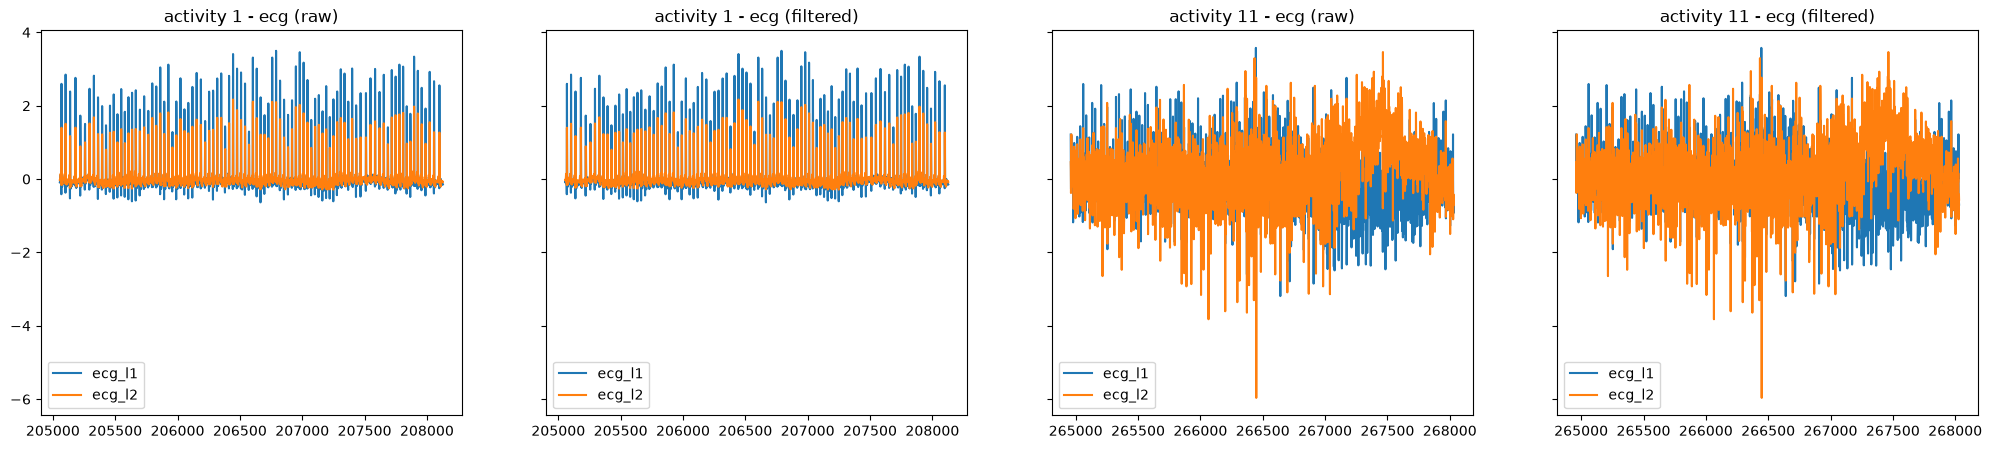

In [15]:
subject_id = 1

ecg_groups = [(group, list_of_measurements) for group, list_of_measurements in data_groups.items() if "ecg" in group]

ecg_df = df[(df["activity_label"] == 1) | (df["activity_label"] == 11)]
ecg_filt_df = df_filtered[(df_filtered["activity_label"] == 1) | (df_filtered["activity_label"] == 11)]

for group, measurements in ecg_groups:
    columns = measurements.copy()
    columns.append("activity_label")
    columns.append("subject_id")

    ecg_subset = ecg_df[columns]
    ecg_filt_subset = ecg_filt_df[columns]
    
    fig, axes = plt.subplots(1, 4, figsize = (25, 5), sharey = True)

    for idx, activity in enumerate([1, 11]):
        raw_data = ecg_subset[(ecg_subset["activity_label"] == activity) & (ecg_subset["subject_id"] == subject_id)]
        filt_data = ecg_filt_subset[(ecg_filt_subset["activity_label"] == activity) & (ecg_filt_subset["subject_id"] == subject_id)]

        # Activity 1: axes 0 and 1, Activity 11: axes 2 and 3
        raw_ax_idx = idx * 2
        filt_ax_idx = idx * 2 + 1

        axes[raw_ax_idx].plot(raw_data[measurements])
        axes[raw_ax_idx].set_title(f"activity {activity} - {group} (raw)")
        axes[raw_ax_idx].legend(measurements)

        axes[filt_ax_idx].plot(filt_data[measurements])
        axes[filt_ax_idx].set_title(f"activity {activity} - {group} (filtered)")
        axes[filt_ax_idx].legend(measurements)

    plt.show()

#### Power Spectral Density Plots

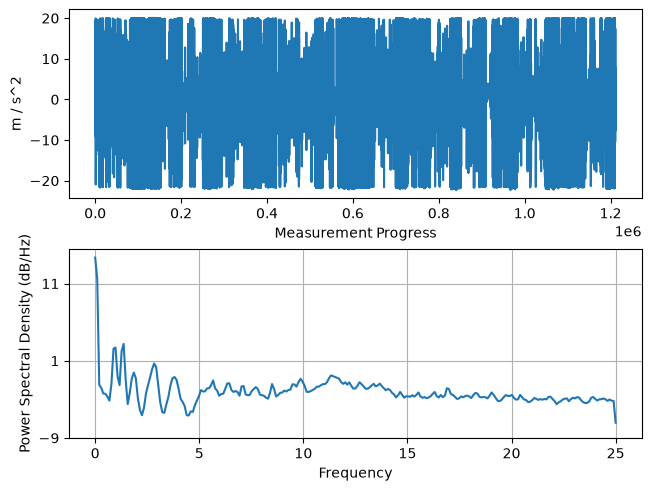

In [17]:
fig, (ax0, ax1) = plt.subplots(2, 1, layout = "constrained")
ax0.plot(df_filtered["id"], df_filtered['x_accel_l_ankle'])
ax0.set_xlabel("Measurement Progress")
ax0.set_ylabel("m / s^2")
ax1.psd(df_filtered['x_accel_l_ankle'], NFFT = 512, Fs = 50)

plt.show()

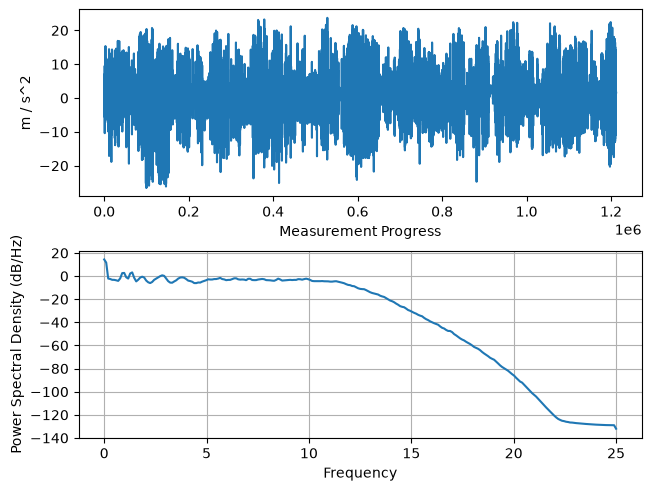

In [18]:
fig, (ax0, ax1) = plt.subplots(2, 1, layout = "constrained")
ax0.plot(df_filtered["id"], df_filtered['x_accel_l_ankle_filt'])
ax0.set_xlabel("Measurement Progress")
ax0.set_ylabel("m / s^2")
ax1.psd(df_filtered['x_accel_l_ankle_filt'], NFFT = 512, Fs = 50)

plt.show()

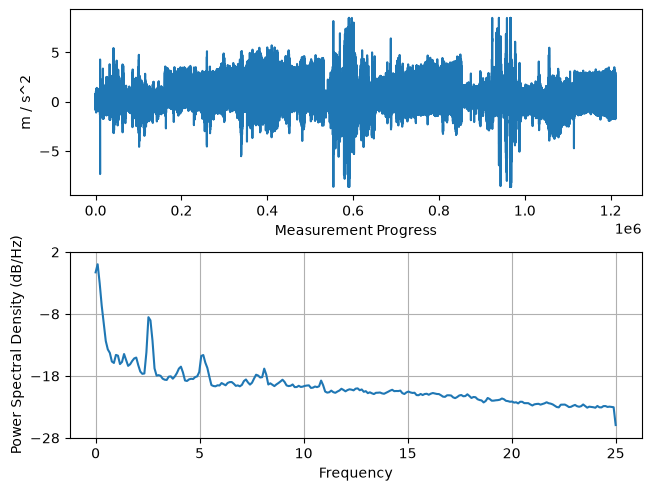

In [19]:
fig, (ax0, ax1) = plt.subplots(2, 1, layout = "constrained")
ax0.plot(df_filtered["id"], df_filtered['ecg_l1'])
ax0.set_xlabel("Measurement Progress")
ax0.set_ylabel("m / s^2")
ax1.psd(df_filtered['ecg_l1'], NFFT = 512, Fs = 50)

plt.show()

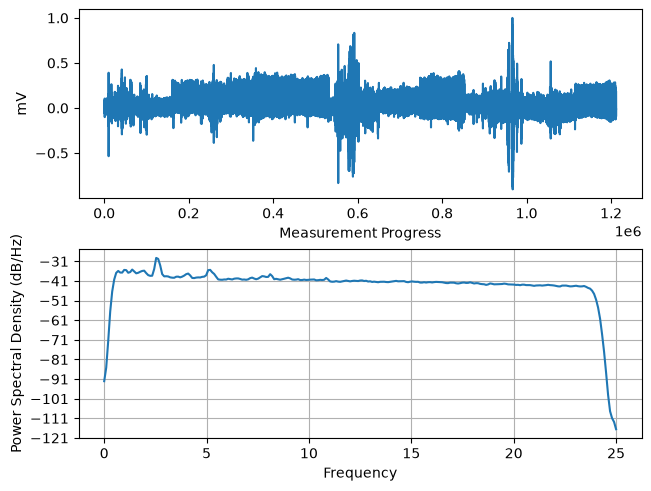

In [20]:
fig, (ax0, ax1) = plt.subplots(2, 1, layout = "constrained")
ax0.plot(df_filtered["id"], df_filtered['ecg_l1_filt'])
ax0.set_xlabel("Measurement Progress")
ax0.set_ylabel("mV")
ax1.psd(df_filtered['ecg_l1_filt'], NFFT = 512, Fs = 50)

plt.show()